In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Bloqueo de semilla global para NumPy
np.random.seed(42)

# Cargar dataset
digits = load_digits()
X = digits.data
y = digits.target

# Bloqueamos también el split con random_state para que la división sea idéntica
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Entorno preparado y semillas bloqueadas (42).")

Entorno preparado y semillas bloqueadas (42).


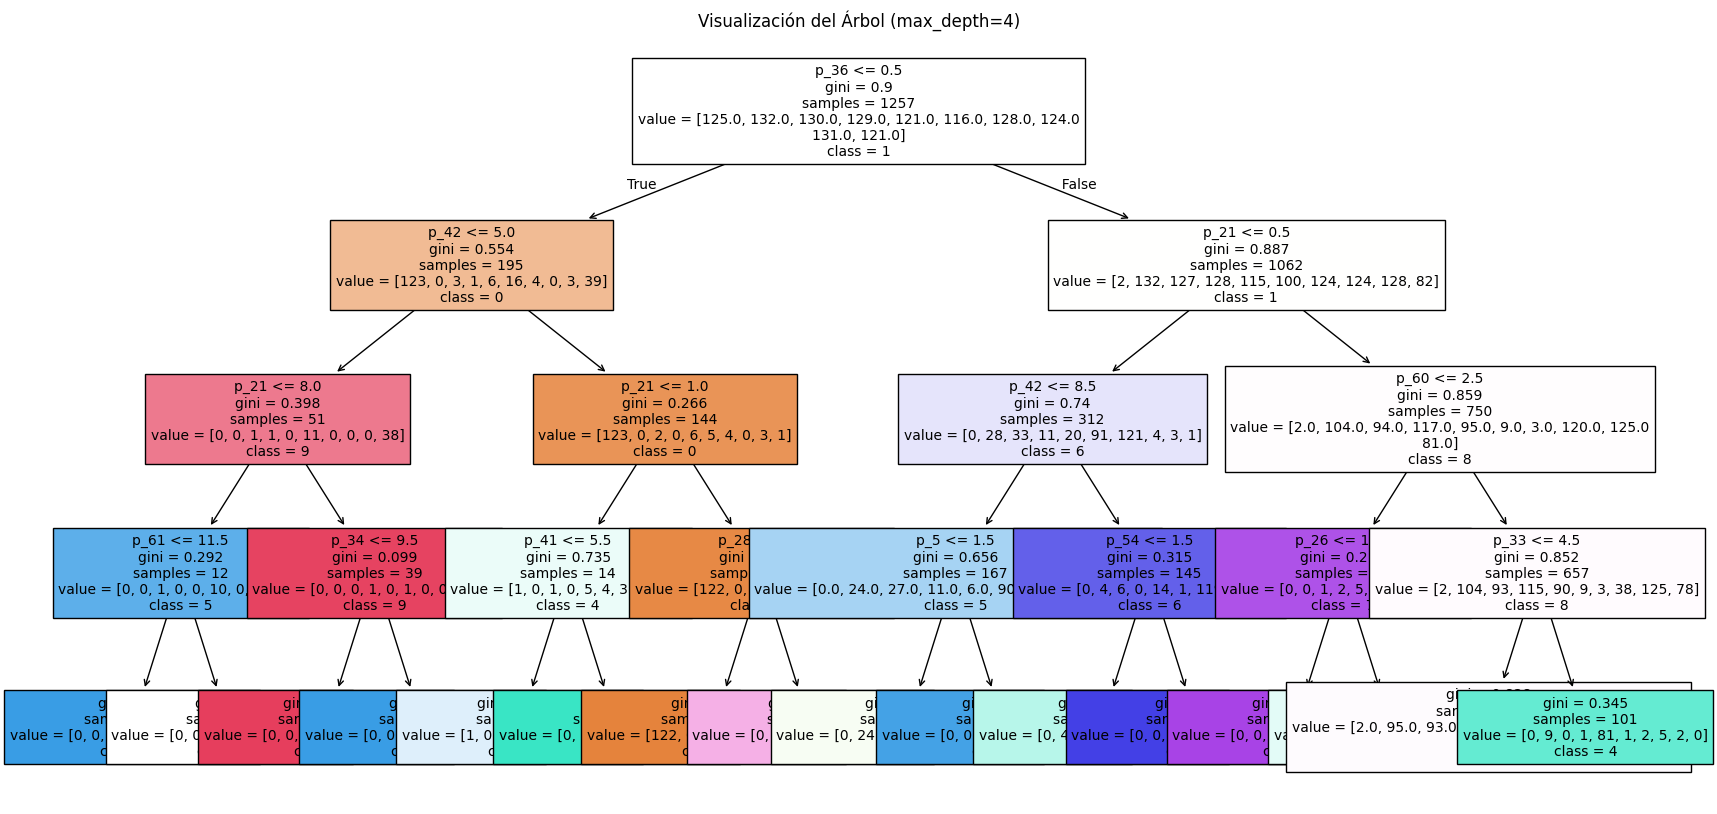

In [2]:
# Entrenamos un árbol para visualizar
clf_viz = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_viz.fit(X_train, y_train)

# Visualización
plt.figure(figsize=(20,10))
plot_tree(clf_viz, filled=True, feature_names=[f"p_{i}" for i in range(64)], 
          class_names=[str(i) for i in range(10)], fontsize=10)
plt.title("Visualización del Árbol (max_depth=4)")
plt.show()

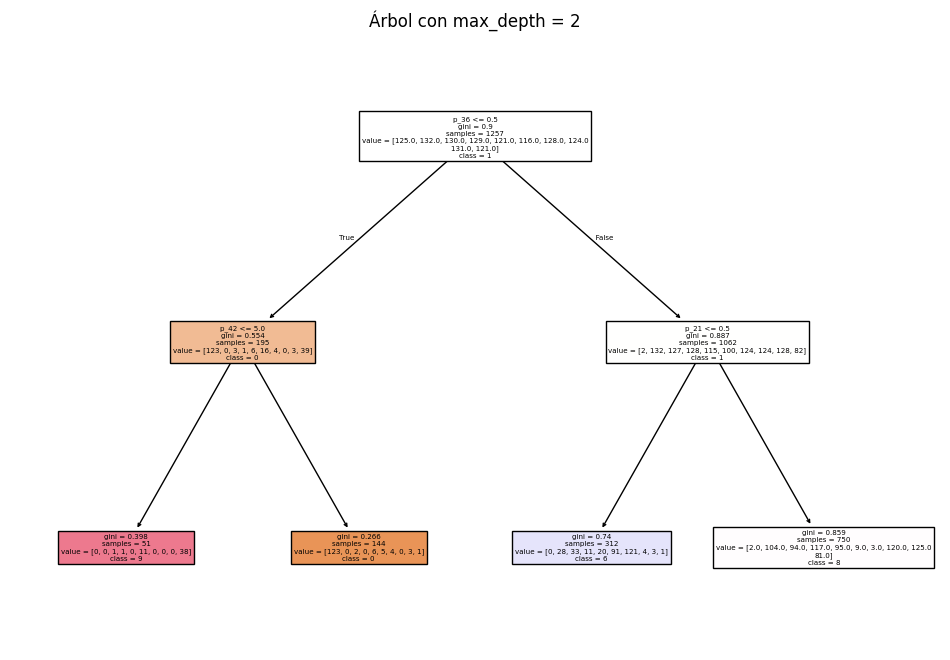

In [3]:
# Modelo con profundidad 2
clf_p2 = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_p2.fit(X_train, y_train)

plt.figure(figsize=(12,8))
plot_tree(clf_p2, filled=True, feature_names=[f"p_{i}" for i in range(64)], 
          class_names=[str(i) for i in range(10)])
plt.title("Árbol con max_depth = 2")
plt.show()

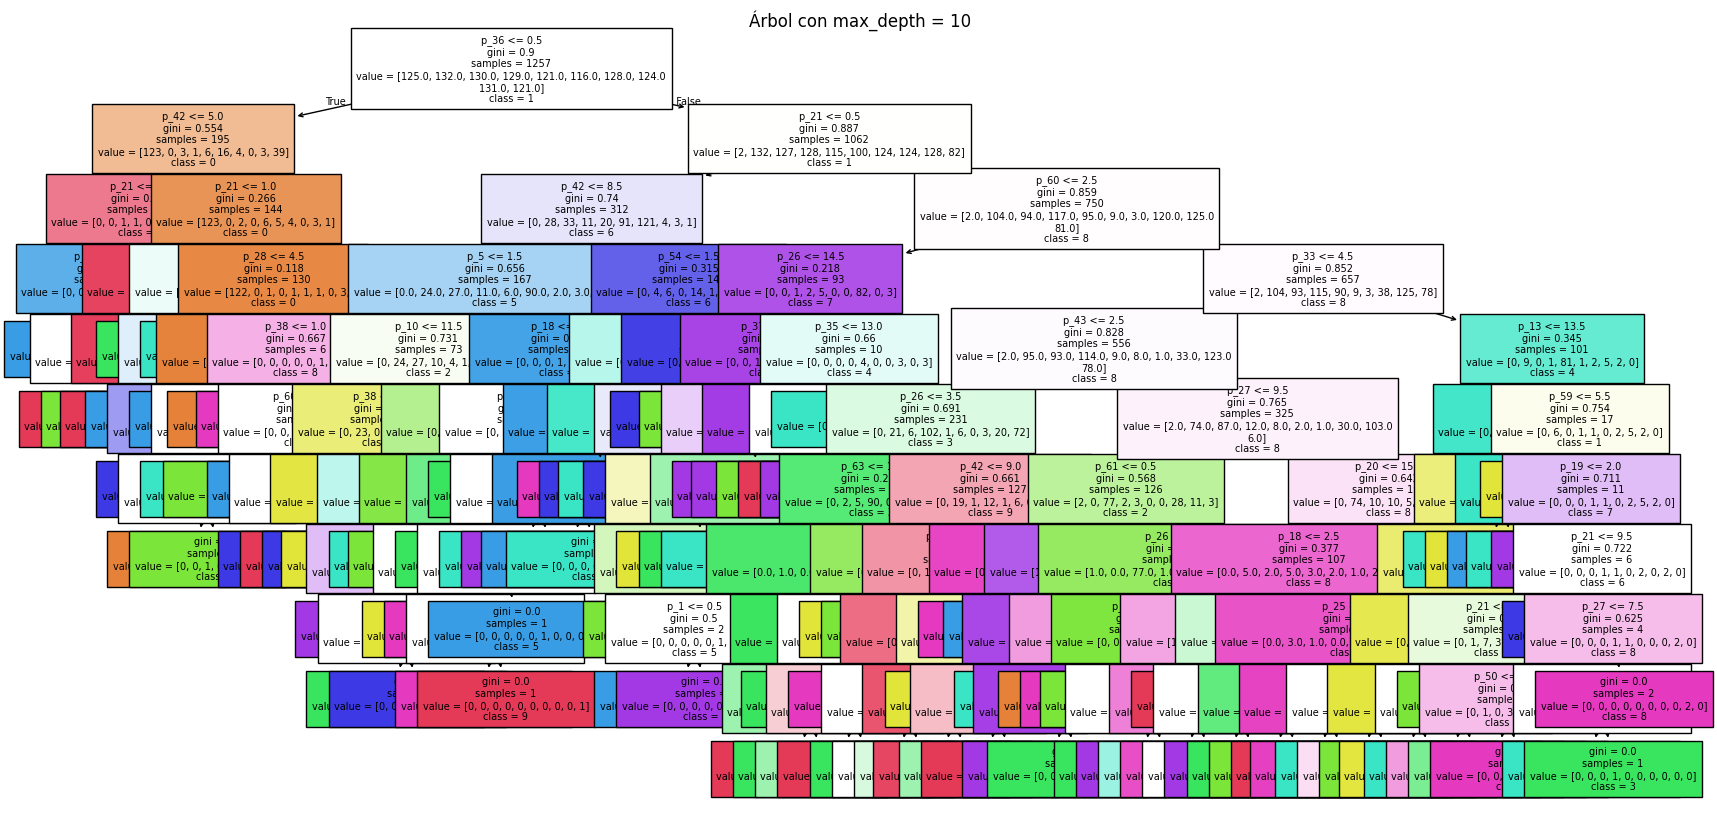

In [4]:
# Modelo con profundidad 10
clf_p10 = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_p10.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf_p10, filled=True, feature_names=[f"p_{i}" for i in range(64)], 
          class_names=[str(i) for i in range(10)], fontsize=7)
plt.title("Árbol con max_depth = 10")
plt.show()

In [5]:
# Entrenamos el modelo solicitado con profundidad 5
clf_p5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_p5.fit(X_train, y_train)

# Analizamos una muestra de test
indice_test = 0
muestra = X_test[indice_test].reshape(1, -1)
valor_real = y_test[indice_test]
prediccion = clf_p5.predict(muestra)[0]

# Obtención del camino de decisión
camino = clf_p5.decision_path(muestra)
num_nodos = camino.getnnz()

print(f"Resultados para la muestra {indice_test}:")
print(f"- Nodos recorridos: {num_nodos}")
print(f"- Valor real: {valor_real}")
print(f"- Predicción: {prediccion}")

Resultados para la muestra 0:
- Nodos recorridos: 6
- Valor real: 6
- Predicción: 6


Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.50      0.16      0.24        50
           2       0.52      0.26      0.34        47
           3       0.45      0.83      0.58        54
           4       0.80      0.80      0.80        60
           5       0.97      0.85      0.90        66
           6       0.85      0.94      0.89        53
           7       0.83      0.69      0.75        55
           8       0.32      0.81      0.46        43
           9       0.81      0.29      0.42        59

    accuracy                           0.66       540
   macro avg       0.70      0.65      0.63       540
weighted avg       0.72      0.66      0.65       540



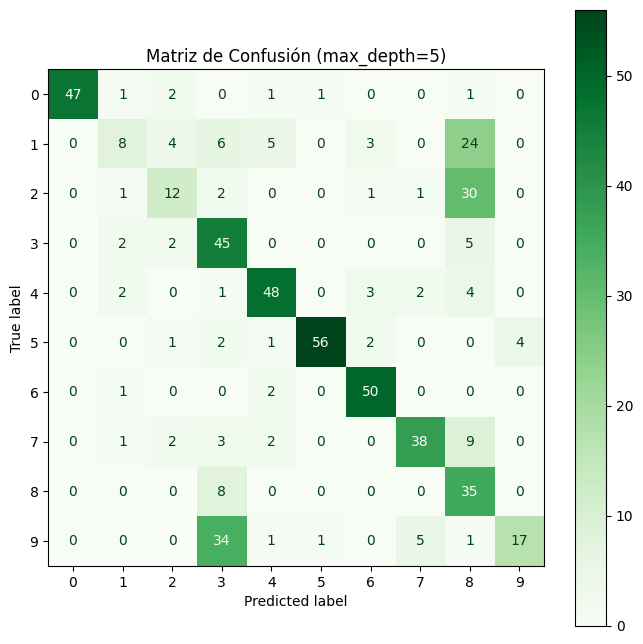

In [6]:
# Generamos predicciones para todo el test con el modelo de profundidad 5
y_pred = clf_p5.predict(X_test)

# Informe de clasificación
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Greens', ax=ax)
plt.title("Matriz de Confusión (max_depth=5)")
plt.show()